In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# FILTER TO LOW PRICE SEGMENT (<25th percentile)
print("\n🎯 FILTERING TO LOW PRICE SEGMENT (<p25)")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Get average price per customer
avg_price = df_quotes.groupby('numero_compte')['mt_apres_remise_ht_devis'].mean().reset_index()
avg_price.columns = ['customer_id', 'avg_price']

# Get 25th percentile
p25 = avg_price['avg_price'].quantile(0.25)

# Filter low price customers
low_price_ids = avg_price[avg_price['avg_price'] <= p25]['customer_id'].tolist()

# Filter data
df_quotes_low_price = df_quotes[df_quotes['numero_compte'].isin(low_price_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"Low price customers (<€{p25:.0f}): {len(low_price_ids):,}")
print(f"Quotes: {len(df_quotes_low_price):,}")

# Save to file
df_quotes_low_price.to_csv('cleaned_quote_data_low_price.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_low_price.csv")


🎯 FILTERING TO LOW PRICE SEGMENT (<p25)
Original customers: 25,716
Low price customers (<€4032): 6,429
Quotes: 8,309

✅ Saved to cleaned_quote_data_low_price.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_low_price.csv')


📊 Original quote data: 8,309 quotes from 6,429 customers

🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 6,429, Quotes: 8,085
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 6,429 customers | 43.9% converters
⏱️  Execution time: 2.5 seconds
✅ SUCCESS! Achieved ≤ 3s target
CREATING FIRST CONVERSION PREDICTION FEATURES (LEAKAGE-FREE)
  Total customers: 6,429
⚡ Processing customers with corrected first-conversion logic...
  Processed 0/6,429 customers
  Processed 5,000/6,429 customers
✅ First-conversion features calculation complete

🔍 VALIDATION REPORT:
   Total customers: 6,429
   First converters: 2,825 (43.9%)
   Never converters: 3,604

📊 Distribution check:
   Converters with 0 historical quotes: 2,392
   Non-converters with 0 historical quotes: 2,911
   Avg historical quotes - Converters: 0.2
   Avg hi

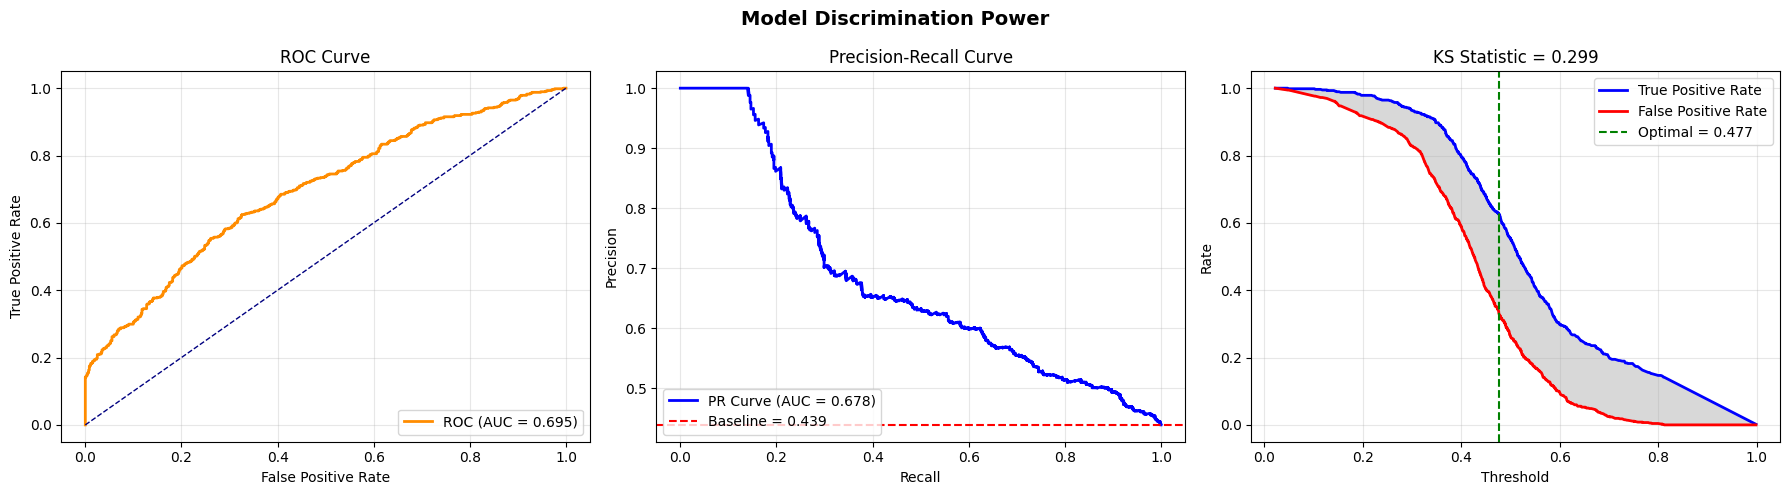

• ROC-AUC: 0.6955
• PR-AUC: 0.6779
• KS Statistic: 0.299 (WEAK discrimination)
• Optimal Threshold: 0.477

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.893
Decile 10 mean prob: 0.182


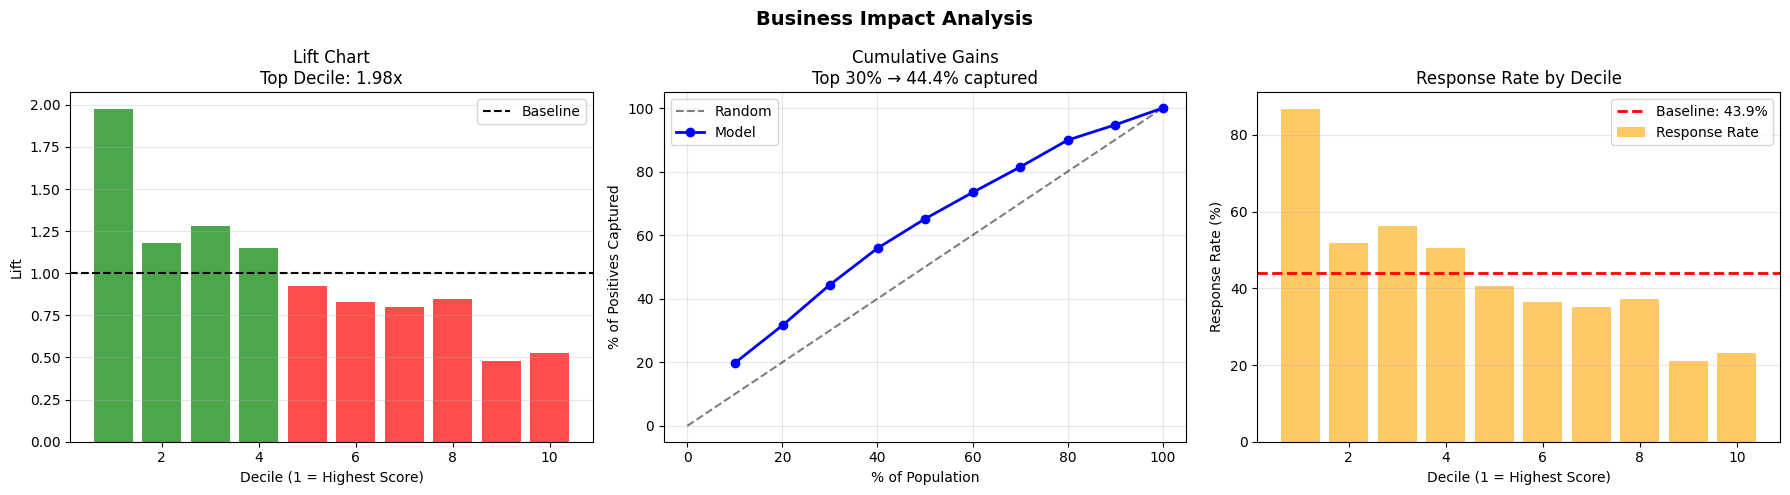

• Top Decile Lift: 0.53x
• Top 30% captures: 44.4% of positives
• Baseline response rate: 43.9%
• Top decile response: 86.8%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


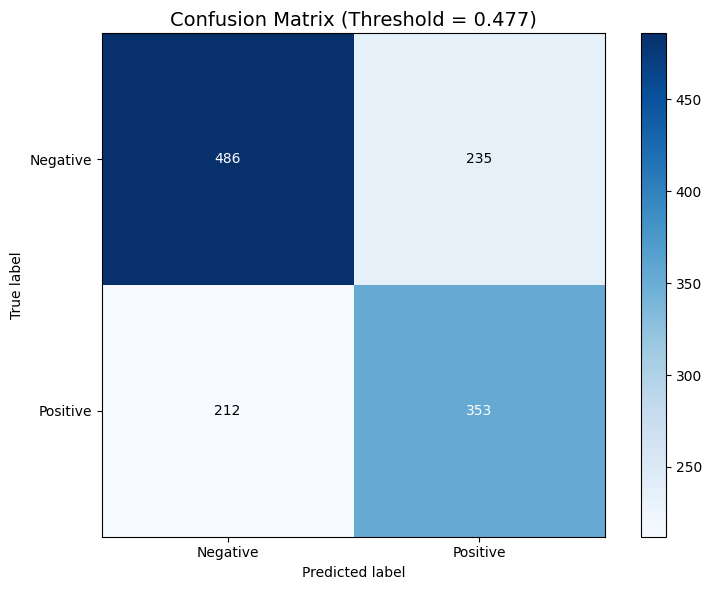

At threshold 0.477:
• Accuracy: 0.652
• Precision: 0.600
• Recall: 0.625
• F1-Score: 0.612
• True Positives: 353
• False Positives: 235
• True Negatives: 486
• False Negatives: 212

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.299 (WEAK discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.53x better than random
   Coverage: Top 30% → 44.4% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.6955 (Excellent if >0.8)
   PR-AUC: 0.6779 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.477
   Precision at threshold: 0.600
   Recall at threshold: 0.625

🔍 FEATURE IMPORTANCE - SUBPOPULATION MODEL

Top 20 Features:
                        feature  importance
176     quote_consistency_score    0.074004
178   decision_efficiency_score    0.033890
181        solution_focus_score    0.028973
240         price_x_consistency    0.019480
55             latest_equipment    0.017033
152             engagement_days    0.016364
197  engagement_velocity_scaled    0.015611
36

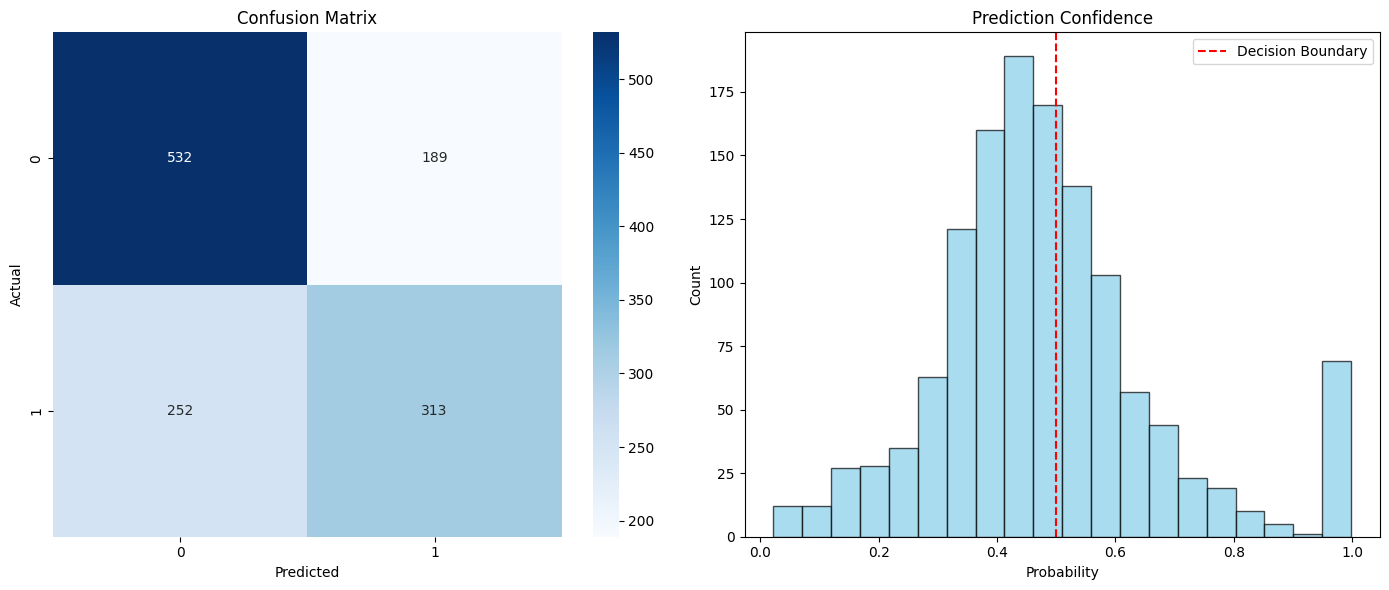

In [4]:
#with redirect_stdout(open('/dev/null', 'w')):
result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])